# Bag of Words & Logistic Regression Classifier Baseline

In [14]:
import csv
import random

import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, f1_score, classification_report

In [15]:
languages = ['af', 'de', 'en', 'es', 'fr', 'id', 'it', 'nl', 'pt', 'sv', 'tl', 'tr']

In [16]:
# Load the train, test, validation data
train_dataset = []
test_dataset = []
validation_dataset = []

train_path = f"dataset/train.csv"
with open(train_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        train_dataset.append(row)

    random.shuffle(train_dataset)
    train_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in train_dataset]
    
test_path = f"dataset/test.csv"
with open(test_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        test_dataset.append(row)

    random.shuffle(test_dataset)
    test_dataset = [{'id': item['id'], 'text': item['text']} for item in test_dataset]

validation_path = f"dataset/validation.csv"
with open(validation_path, 'r', encoding='utf-8') as f:
    reader = csv.DictReader(f)
    for row in reader:
        validation_dataset.append(row)

    random.shuffle(validation_dataset)
    validation_dataset = [{'id': item['id'], 'text': item['text'], 'lang': item['lang']} for item in validation_dataset]

## Visualizing the data

In [17]:
# Visualize the training dataset
print("Sample training data:")
train_df = pd.DataFrame(train_dataset)
train_df.head(10)

Sample training data:


,id,text,lang
0,7638,adicionar a consulta no dentista na sexta-feir...,pt
1,5878,mahal ko ang walang hanggang boses sa mang-aaw...,tl
2,7318,jag måste vara på gotland för denna kommande h...,sv
3,9697,ga door met het voorlezen van moby dick,nl
4,2636,demp volume nou,af
5,15206,dammi aggiornamenti del mio facebook ogni tre ore,it
6,5029,haberleri getir,tr
7,2670,haal nieuws bij n. o. s.,nl
8,8115,entre um de maio e trinta e um de dezembro que...,pt
9,10221,het opzetten van een voedselverwerkingsbedrijf...,nl


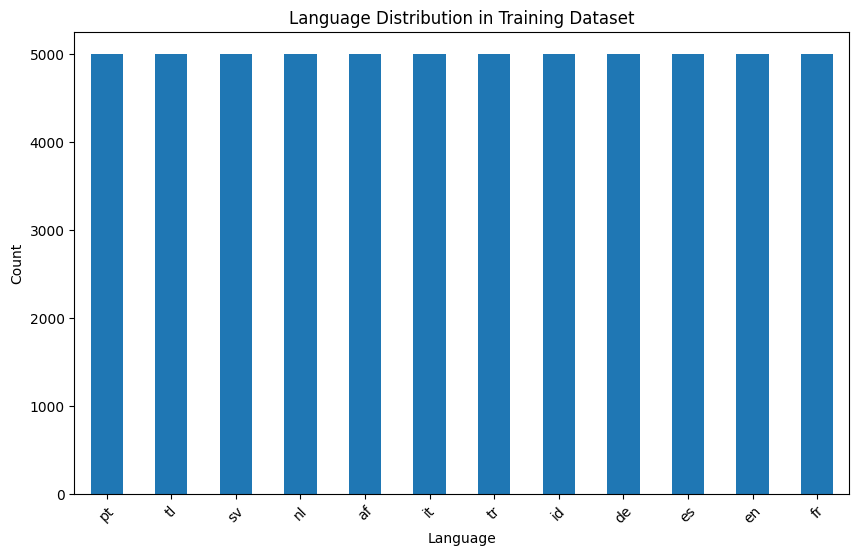

In [18]:
plt.figure(figsize=(10, 6))
train_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Training Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [19]:
# Visualize the test dataset
print("Sample test data:")
test_df = pd.DataFrame(test_dataset)
test_df.head(10)

Sample test data:


,id,text
0,8126,programar un evento de reunión en mi calendario
1,15862,revisar correo electrónico de recibido de mamá
2,10053,come si fa la pizza
3,8868,paalalahanan akong tawagan mo si nanay tuwing ...
4,9561,avvia radio centocinque alla radio
5,5157,olly spegni la luce del soggiorno
6,10853,alisin iyan diyan
7,400,mulai putar
8,12008,may mga nakakatuwang kaganapan ba sa l. a. ngayon
9,8302,remover reunião da próxima segunda feira


In [20]:
# Visualize the validation dataset
print("Sample validation data:")
validation_df = pd.DataFrame(validation_dataset)
validation_df.head(10)

Sample validation data:


,id,text,lang
0,12438,quali sono gli orari dei treni da milano a ven...,it
1,415,verander my kamer ligte sodat ek 'n goeie slaa...,af
2,7893,please give me an update on the election every...,en
3,14421,où est le restaurant italien le plus proche,fr
4,5666,ang lagay ng panahon ay na update sa paggamit ...,tl
5,3968,indie,de
6,5565,nagkabalikan ba sina john lloyd at bea,tl
7,7495,erinnere mich an mein interview morgen,de
8,14971,berätta hur världen började,sv
9,13354,vad är svaret på två plus två,sv


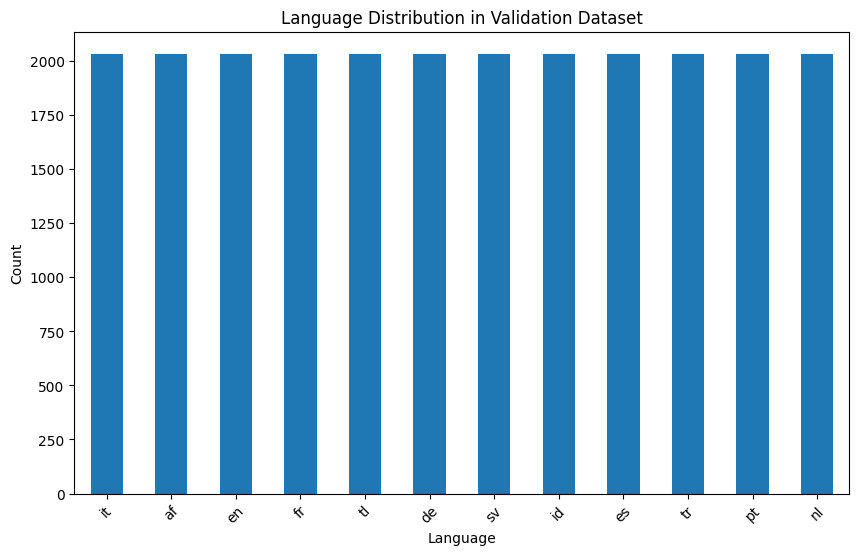

In [21]:
plt.figure(figsize=(10, 6))
validation_df['lang'].value_counts().plot(kind='bar')
plt.title('Language Distribution in Validation Dataset')
plt.xlabel('Language')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Model Training

In [22]:
# Split the data into features and labels
X_train = [item['text'] for item in train_dataset]
y_train = [item['lang'] for item in train_dataset]

X_test = [item['text'] for item in test_dataset]

X_val = [item['text'] for item in validation_dataset]
y_val = [item['lang'] for item in validation_dataset]

In [23]:
# Create a BoW 
bow_vectorizer = CountVectorizer(lowercase=True, strip_accents=None)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)
X_val_bow = bow_vectorizer.transform(X_val)

In [24]:
classifier = LogisticRegression()
classifier.fit(X_train_bow, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation

In [25]:
y_pred = classifier.predict(X_val_bow)

accuracy = accuracy_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred, average='macro')

print(f"Accuracy: {accuracy*100:.4f}%")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 97.0692%
F1 Score: 0.9711

Classification Report:
              precision    recall  f1-score   support

          af       0.97      0.95      0.96      2033
          de       0.99      0.97      0.98      2033
          en       0.98      0.97      0.98      2033
          es       0.98      0.95      0.97      2033
          fr       0.99      0.97      0.98      2033
          id       0.98      0.99      0.99      2033
          it       0.99      0.97      0.98      2033
          nl       0.97      0.95      0.96      2033
          pt       0.96      0.98      0.97      2033
          sv       0.99      0.97      0.98      2033
          tl       1.00      0.98      0.99      2033
          tr       0.85      0.99      0.92      2033

    accuracy                           0.97     24396
   macro avg       0.97      0.97      0.97     24396
weighted avg       0.97      0.97      0.97     24396



In [27]:
# Run your prediction on the test set and save the results to a CSV file
y_test_pred = classifier.predict(X_test_bow)

output_df = pd.DataFrame({'id': [item['id'] for item in test_dataset], 'lang': y_test_pred})
output_df.to_csv('prediction_results.csv', index=False)